In [1]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

# Read the CSV file into a pandas DataFrame
csv_file_path = os.path.join(path, 'diabetes.csv')
df = pd.read_csv(csv_file_path)

print("CSV file loaded successfully. Here are the first 5 rows:")
print(df.head())

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import Binarizer

In [6]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [8]:
diabetes_data = pd.read_csv('diabetes.csv')

print(diabetes_data['Outcome'].value_counts())

diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [9]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
def get_clf_eval(y_test, pred=None, pred_proba=None):

    confusion = confusion_matrix(y_test, pred)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print("오차 행렬")
    print(confusion)

    print('정확도: {0:.4f}'.format(accuracy))
    print('정밀도: {0:.4f}'.format(precision))
    print('재현율: {0:.4f}'.format(recall))
    print('F1: {0:.4f}'.format(f1))
    print('ROC AUC: {0:.4f}'.format(roc_auc))

In [11]:
def precision_recall_curve_plot(y_test, pred_proba_c1):

    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

    plt.plot(thresholds, precisions[0:len(thresholds)], label='precision')
    plt.plot(thresholds, recalls[0:len(thresholds)], label='recall')

    plt.xlabel('Threshold')
    plt.ylabel('Precision / Recall')
    plt.legend()

    plt.show()


In [12]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=156,
    stratify=y
)

In [14]:
lr_clf = LogisticRegression(solver='liblinear')

lr_clf.fit(X_train, y_train)

pred = lr_clf.predict(X_test)

pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727
정밀도: 0.7111
재현율: 0.5926
F1: 0.6465
ROC AUC: 0.8083


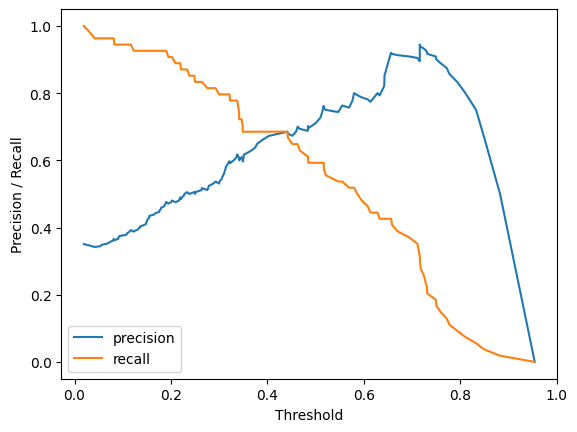

In [15]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]

precision_recall_curve_plot(y_test, pred_proba_c1)

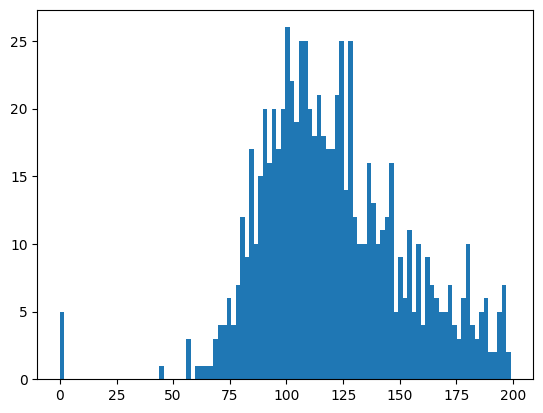

In [16]:
plt.hist(diabetes_data['Glucose'], bins=100)

plt.show()

In [17]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

total_count = diabetes_data['Glucose'].count()

for feature in zero_features:

    zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()

    print('{0} 0 건수는 {1}, 퍼센트는 {2:.2f}%'.format(
        feature,
        zero_count,
        100 * zero_count / total_count
    ))

Glucose 0 건수는 5, 퍼센트는 0.65%
BloodPressure 0 건수는 35, 퍼센트는 4.56%
SkinThickness 0 건수는 227, 퍼센트는 29.56%
Insulin 0 건수는 374, 퍼센트는 48.70%
BMI 0 건수는 11, 퍼센트는 1.43%


In [18]:
mean_zero_features = diabetes_data[zero_features].mean()

diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero_features)

In [19]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=156,
    stratify=y
)

In [22]:
lr_clf = LogisticRegression()

lr_clf.fit(X_train, y_train)

pred = lr_clf.predict(X_test)

pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987
정밀도: 0.7674
재현율: 0.6111
F1: 0.6804
ROC AUC: 0.8433


In [23]:
def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):

    for threshold in thresholds:

        binarizer = Binarizer(threshold=threshold)

        pred = binarizer.fit_transform(pred_proba_c1)

        print('\nThreshold:', threshold)

        get_clf_eval(y_test, pred, pred_proba_c1)

In [24]:
thresholds = [0.3,0.33,0.36,0.39,0.42,0.45,0.48,0.50]

pred_proba = lr_clf.predict_proba(X_test)

get_eval_by_threshold(
    y_test,
    pred_proba[:,1].reshape(-1,1),
    thresholds
)


Threshold: 0.3
오차 행렬
[[67 33]
 [11 43]]
정확도: 0.7143
정밀도: 0.5658
재현율: 0.7963
F1: 0.6615
ROC AUC: 0.8433

Threshold: 0.33
오차 행렬
[[72 28]
 [12 42]]
정확도: 0.7403
정밀도: 0.6000
재현율: 0.7778
F1: 0.6774
ROC AUC: 0.8433

Threshold: 0.36
오차 행렬
[[76 24]
 [15 39]]
정확도: 0.7468
정밀도: 0.6190
재현율: 0.7222
F1: 0.6667
ROC AUC: 0.8433

Threshold: 0.39
오차 행렬
[[78 22]
 [16 38]]
정확도: 0.7532
정밀도: 0.6333
재현율: 0.7037
F1: 0.6667
ROC AUC: 0.8433

Threshold: 0.42
오차 행렬
[[84 16]
 [18 36]]
정확도: 0.7792
정밀도: 0.6923
재현율: 0.6667
F1: 0.6792
ROC AUC: 0.8433

Threshold: 0.45
오차 행렬
[[85 15]
 [18 36]]
정확도: 0.7857
정밀도: 0.7059
재현율: 0.6667
F1: 0.6857
ROC AUC: 0.8433

Threshold: 0.48
오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987
정밀도: 0.7447
재현율: 0.6481
F1: 0.6931
ROC AUC: 0.8433

Threshold: 0.5
오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987
정밀도: 0.7674
재현율: 0.6111
F1: 0.6804
ROC AUC: 0.8433


In [25]:
binarizer = Binarizer(threshold=0.48)

pred_th_048 = binarizer.fit_transform(
    pred_proba[:,1].reshape(-1,1)
)

get_clf_eval(y_test, pred_th_048, pred_proba[:,1])

오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987
정밀도: 0.7447
재현율: 0.6481
F1: 0.6931
ROC AUC: 0.8433
